In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path


In [ ]:
# 現在の作業ディレクトリ取得
cwd = Path.cwd()
#print("Current working directory:", cwd)

# logsフォルダ内のCSV
log_dir = cwd / "logs"
if not log_dir.exists():
    log_dir = cwd / "tools" / "logs"

csv_path = log_dir / "20260708_1937_type8a_MPQ.csv"


print("CSV path:", csv_path)
df = pd.read_csv(csv_path)
df = df.loc[:, df.columns.notna()]          # NaN ラベル除外
df = df.loc[:, df.columns != ""]            # 空文字ラベル除外
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]  # Unnamed 列除外
#print(df)

Current working directory: c:\Users\sato1\Documents\git\mouse_type8_VScode\mouse_type8\tools
CSV path: c:\Users\sato1\Documents\git\mouse_type8_VScode\mouse_type8\tools\logs\20260708_1937_type8a_MPQ.csv


C:\Users\sato1\AppData\Local\Temp\ipykernel_29444\3014970254.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


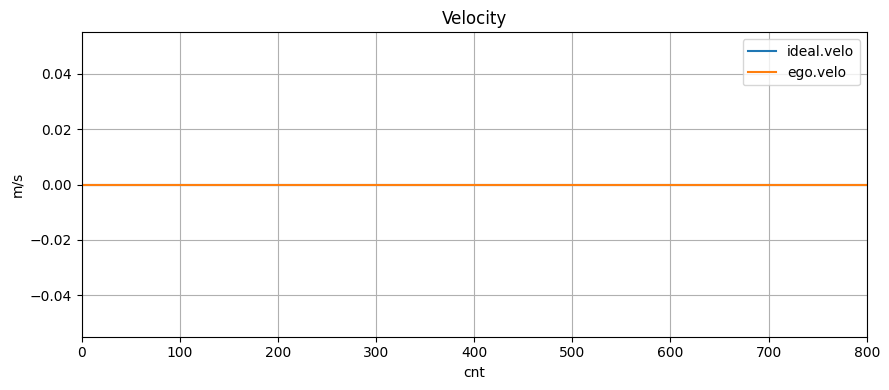

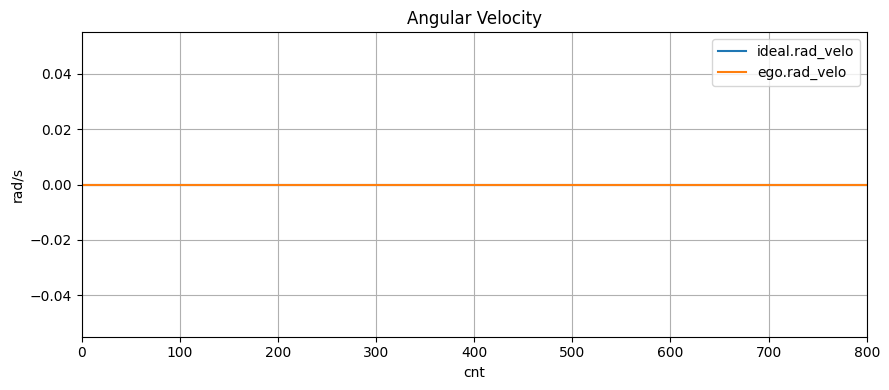

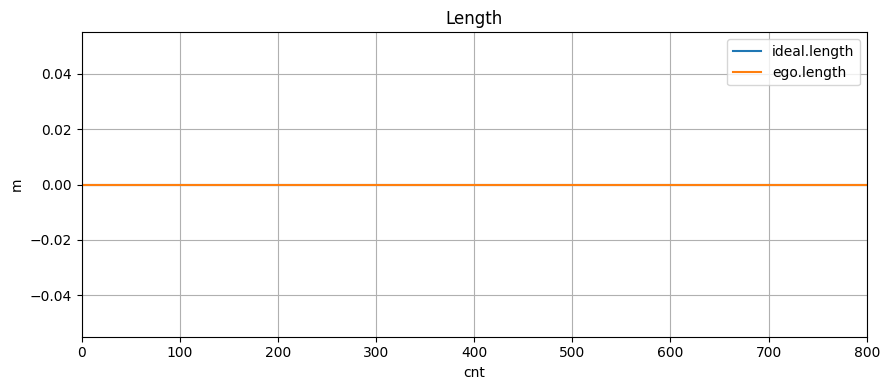

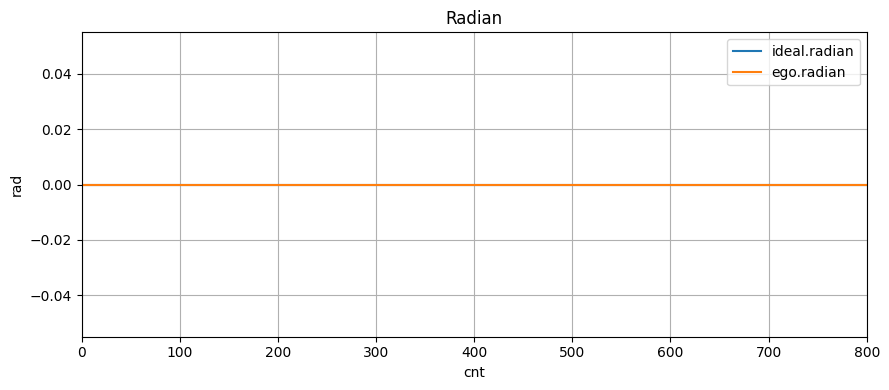

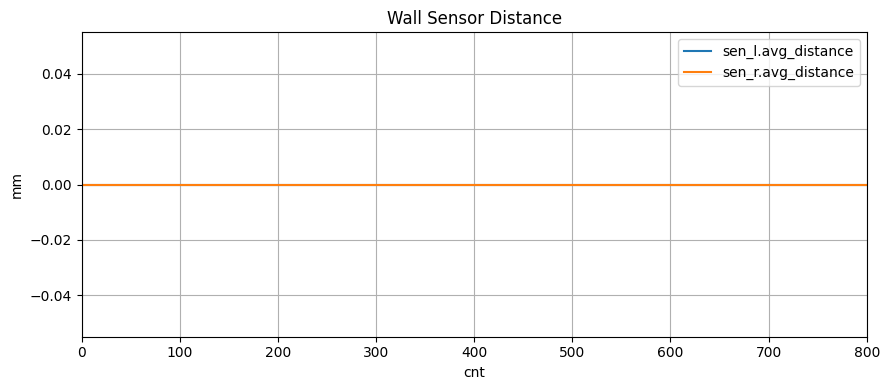

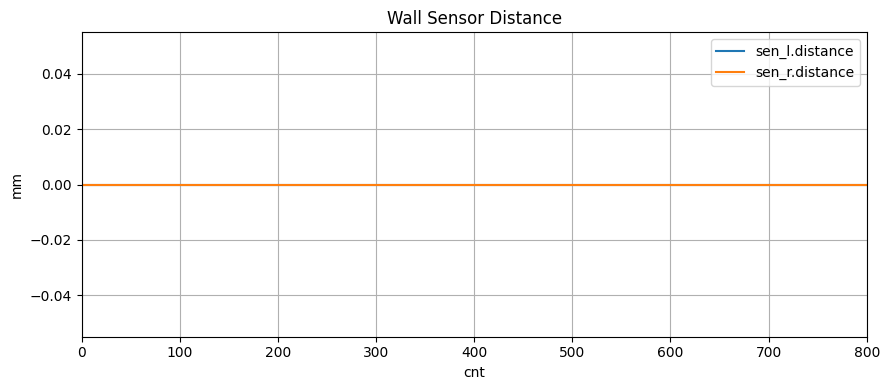

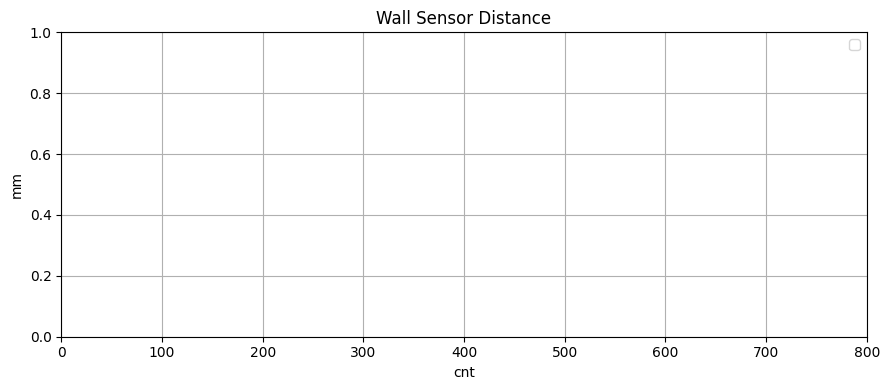

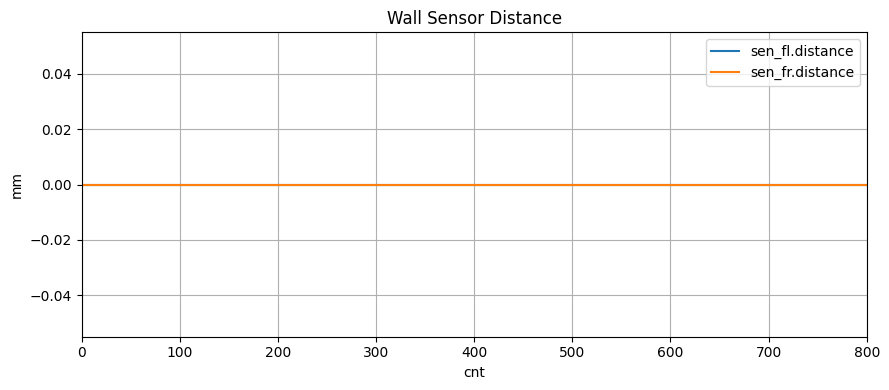

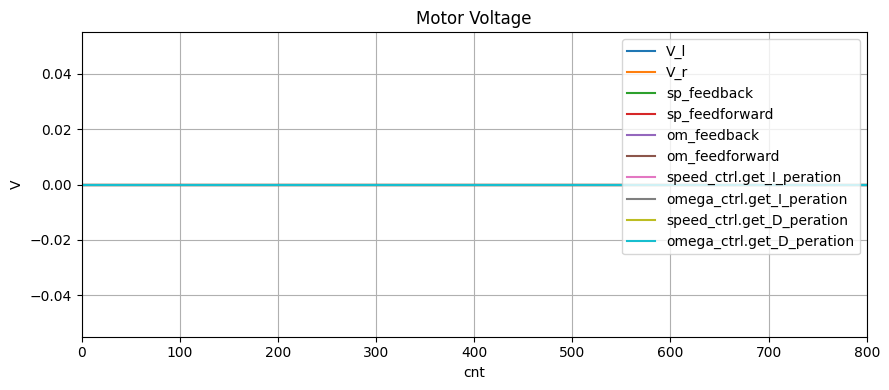

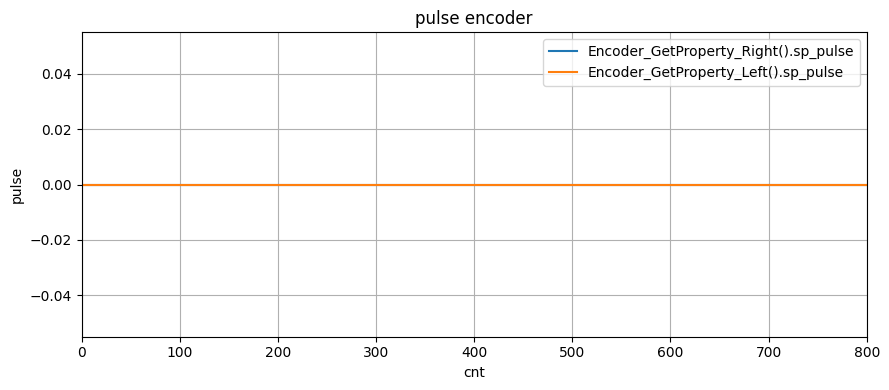

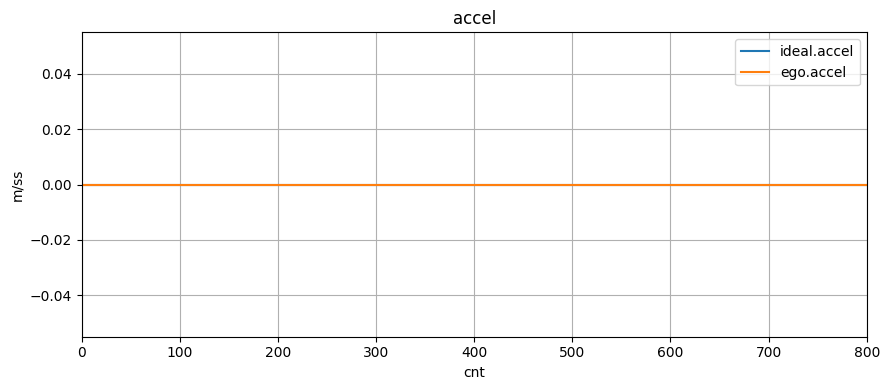

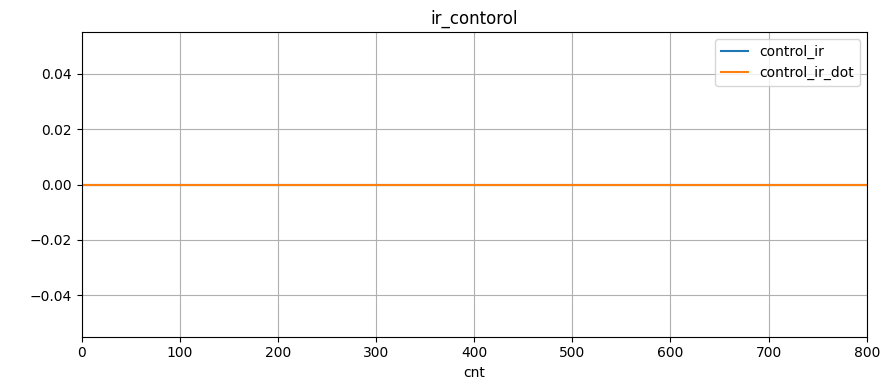

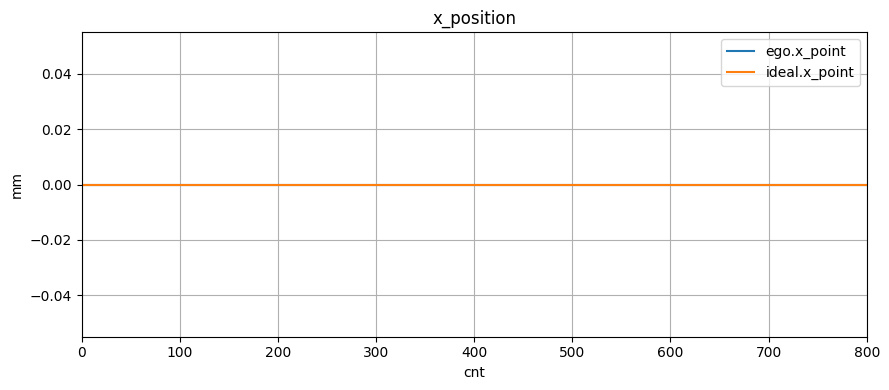

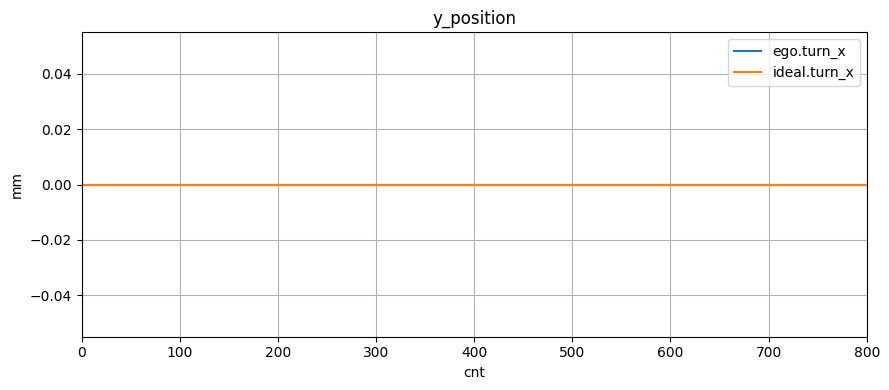

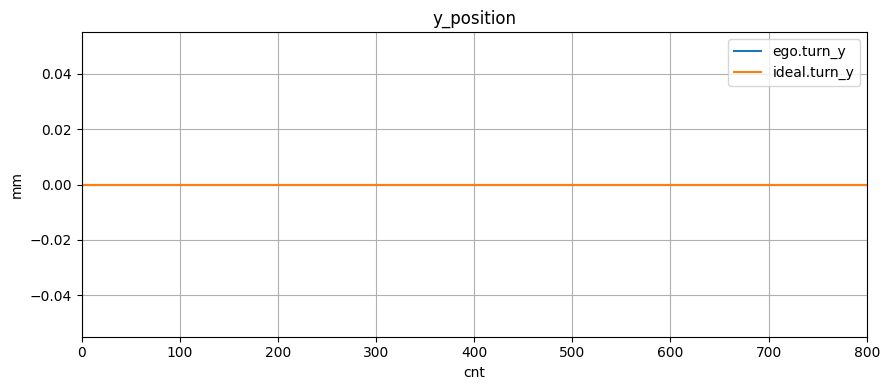

In [3]:
x = df["cnt"]

def plot_group(cols, title, ylabel="value"):
    plt.figure(figsize=(9, 4))
    for c in cols:
        if c in df.columns:
            plt.plot(x, df[c], label=c)
    plt.title(title)
    plt.xlim([0,800])
    plt.xlabel("cnt")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

# ===== プロット群 =====

# 1. 速度
plot_group(["ideal.velo", "ego.velo"], "Velocity", "m/s")

# 2. 角速度
plot_group(["ideal.rad_velo", "ego.rad_velo"], "Angular Velocity", "rad/s")

# 3. 走行距離
plot_group(["ideal.length", "ego.length"], "Length", "m")

# 4. 角度
plot_group(["ideal.radian", "ego.radian"], "Radian", "rad")

# 5. 壁センサ距離
plot_group(["sen_l.avg_distance", "sen_r.avg_distance"], "Wall Sensor Distance", "mm")

plot_group(["sen_l.distance", "sen_r.distance"], "Wall Sensor Distance", "mm")

plot_group(["sen_fl.avg_distance", "sen_fr.avg_distance"], "Wall Sensor Distance", "mm")

plot_group(["sen_fl.distance", "sen_fr.distance"], "Wall Sensor Distance", "mm")


# 6. モータ電圧
plot_group(["V_l", "V_r","sp_feedback","sp_feedforward","om_feedback","om_feedforward","speed_ctrl.get_I_peration","omega_ctrl.get_I_peration","speed_ctrl.get_D_peration","omega_ctrl.get_D_peration"], "Motor Voltage", "V")

plot_group(["Encoder_GetProperty_Right().sp_pulse","Encoder_GetProperty_Left().sp_pulse"], "pulse encoder", "pulse")

plot_group(["ideal.accel","ego.accel"], "accel", "m/ss")

plot_group(["control_ir","control_ir_dot"], "ir_contorol", " ")

plot_group(["ego.x_point", "ideal.x_point"], "x_position", "mm")

plot_group(["ego.turn_x", "ideal.turn_x",], "y_position", "mm")

plot_group(["ego.turn_y", "ideal.turn_y",], "y_position", "mm")

plt.show()

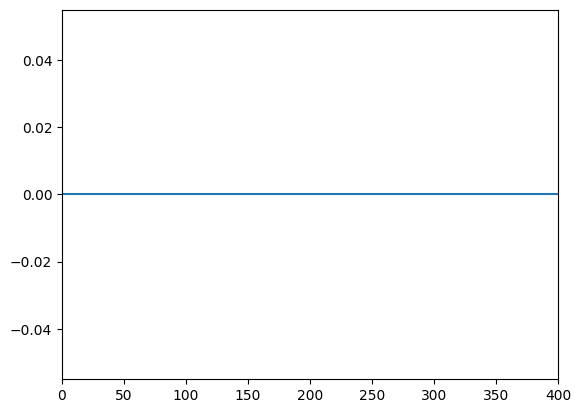

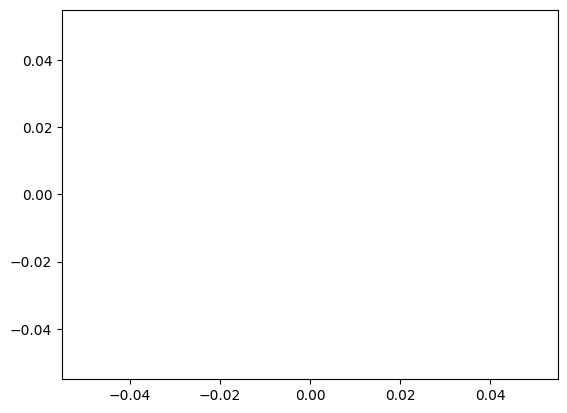

In [4]:
y = df["sen_l.distance"]- df["sen_l.avg_distance"]
plt.plot(x,y)
#plt.plot(x,df["sen_l.distance"])
#plt.plot(x,df["sen_l.avg_distance"])
plt.xlim([0,400])
plt.show()

plt.plot(df["ego.length"],df["sen_l.distance"])
plt.plot(df["ego.length"],y)

plt.show()

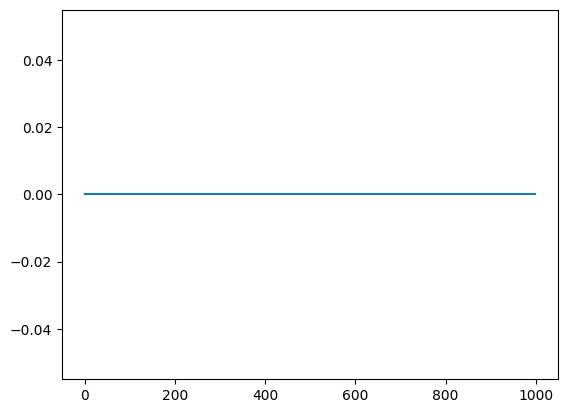

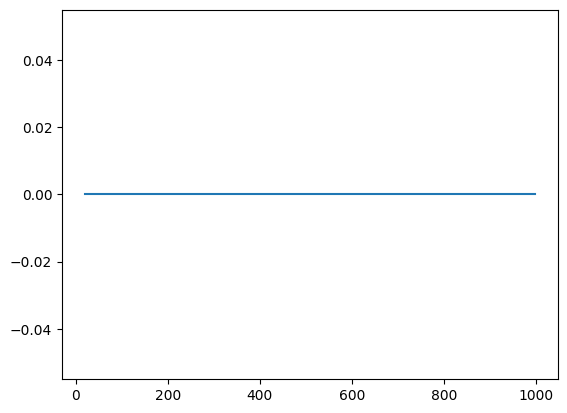

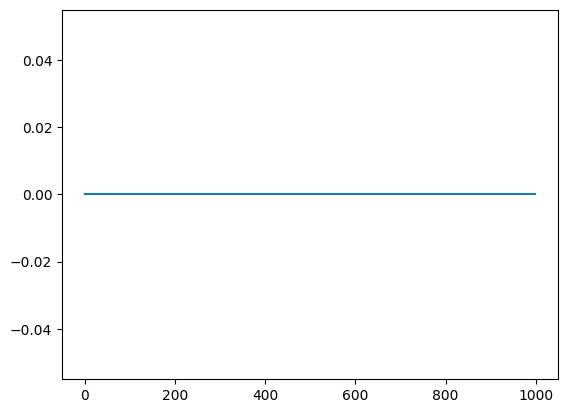

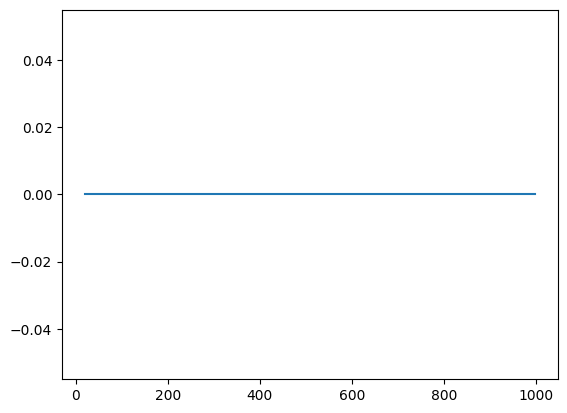

In [5]:
y = df["Encoder_GetProperty_Right().sp_pulse"]
y_ma20 = y.rolling(window=20).mean()
plt.plot(x,y)
plt.show()

plt.plot(x,y_ma20)
plt.show()

y = df["Encoder_GetProperty_Left().sp_pulse"]
y_ma20 = y.rolling(window=20).mean()
plt.plot(x,y)
plt.show()
plt.plot(x,y_ma20)
plt.show()


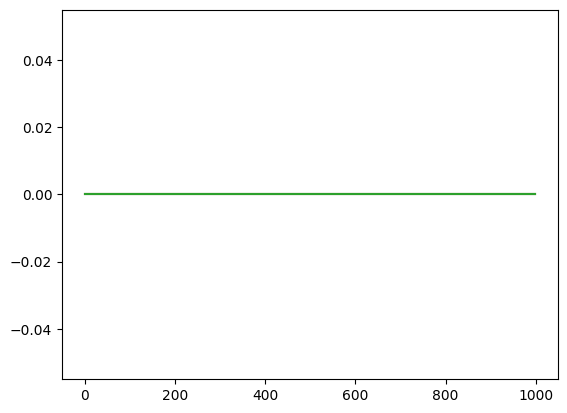

In [6]:
y = df["sen_l.distance"]- df["sen_l.avg_distance"]
plt.plot(x,y)
plt.plot(x,df["sen_l.distance"])
plt.plot(x,df["sen_l.avg_distance"])
plt.show()